In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
data=load_breast_cancer()
df=pd.DataFrame(data.data,columns=data.feature_names)
print(df.shape)
print(df.columns.to_list())
print(df.dtypes)
print(df.head())
print(df.isnull().sum())

(569, 30)
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              fl

In [ ]:
df['target']=data.target
print(df['target'].value_counts())

target
1    357
0    212
Name: count, dtype: int64


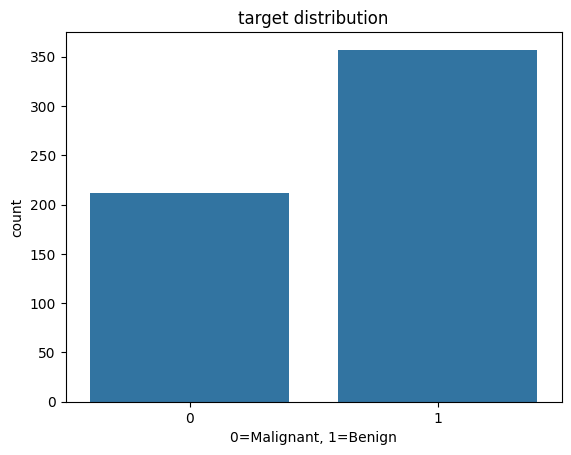

In [ ]:
sns.countplot(data=df,x='target')
plt.title("target distribution")
plt.xlabel('0=Malignant, 1=Benign')
plt.show()

In [ ]:
x=df.drop('target',axis=1)
y=df['target']
print("x shape: ",x.shape)
print("y shape: ",y.shape)
print("columns: ",x.columns.to_list())

x shape:  (569, 30)
y shape:  (569,)
columns:  ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("x_train shape: ",x_train.shape)
print("x_test shape: ",x_test.shape)
print("y_train  target rate ",y_train.mean().round(2))
print("y_test target rate ",y_test.mean().round(2))



x_train shape:  (455, 30)
x_test shape:  (114, 30)
y_train  target rate  0.63
y_test target rate  0.62


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [ ]:
models={
    'logistic regression':LogisticRegression(random_state=42,max_iter=1000),
    'svm':SVC(random_state=42,probability=True),
    'random forest':RandomForestClassifier(random_state=42,max_depth=5,n_estimators=100),
    'knn':KNeighborsClassifier(n_neighbors=5),
    'xgboost':XGBClassifier(n_estimators=100,random_state=42,learning_rate=0.01,subsamples=5,eval_metric='logloss',verbose=0)
}

In [ ]:
from sklearn.model_selection import StratifiedKFold,cross_val_score
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
print("cross validation successfullt created")

cross validation successfullt created


In [ ]:
result={}
for name,model in models.items():
  full_pipeline=Pipeline([('scaler',StandardScaler()),('model',model)])
  acc_scores=cross_val_score(full_pipeline,x_train,y_train,cv=cv,scoring='accuracy')
  recall_scores=cross_val_score(full_pipeline,x_train,y_train,cv=cv,scoring='recall')
  roc_auc=cross_val_score(full_pipeline,x_train,y_train,cv=cv,scoring='roc_auc')
  result['model']={
      'accuracy':acc_scores.mean().round(4),
      'recall':recall_scores.mean().round(4),
      'roc_auc':roc_auc.mean().round(4)
  }
  print(f"{name} done")
  print(f"{name}")
  print(f"accuracy:{acc_scores}")
  print(f"recall:{recall_scores}")
  print(f"roc_auc:{roc_auc}")

print("all model successfully trained")
result_df=pd.DataFrame(result).T
result_df=result_df.sort_values('recall',ascending=False)
print("comaprision results with recall")
print(result_df.to_string())


logistic regression done
logistic regression
accuracy:[0.95604396 0.94505495 0.97802198 0.98901099 0.95604396]
recall:[0.98275862 0.96491228 0.96491228 1.         0.98245614]
roc_auc:[0.99634274 0.98400413 1.         0.99845201 0.99638803]
svm done
svm
accuracy:[0.98901099 0.96703297 0.98901099 0.96703297 0.95604396]
recall:[1.         1.         0.98245614 0.96491228 0.98245614]
roc_auc:[0.99947753 0.9871001  1.         0.99380805 0.99535604]
random forest done
random forest
accuracy:[0.98901099 0.95604396 0.92307692 0.94505495 0.96703297]
recall:[0.98275862 0.98245614 0.92982456 0.96491228 1.        ]
roc_auc:[0.99947753 0.98503612 0.97678019 0.97781218 0.999484  ]
knn done
knn
accuracy:[0.97802198 0.96703297 0.95604396 0.96703297 0.94505495]
recall:[1.         1.         1.         1.         0.98245614]
roc_auc:[0.99738767 0.98219814 0.99380805 0.96594427 0.99226006]
xgboost done
xgboost
accuracy:[0.96703297 0.94505495 0.87912088 0.96703297 0.94505495]
recall:[1.         1.        

In [ ]:
result={}
for name,model in models.items():
  full_pipeline=Pipeline([('scaler',StandardScaler()),('model',model)])
  acc_scores=cross_val_score(full_pipeline,x_train,y_train,cv=cv,scoring='accuracy').mean().round(4)
  recall_scores=cross_val_score(full_pipeline,x_train,y_train,cv=cv,scoring='recall').mean().round(4)
  roc_auc=cross_val_score(full_pipeline,x_train,y_train,cv=cv,scoring='roc_auc').mean().round(4)
  print(f"{name}")
  print(f"accuracy : {acc_scores}")
  print(f"recall : {recall_scores}")
  print(f"roc_auc : {roc_auc}")


logistic regression
accuracy : 0.9648
recall : 0.979
roc_auc : 0.995
svm
accuracy : 0.9736
recall : 0.986
roc_auc : 0.9951
random forest
accuracy : 0.956
recall : 0.972
roc_auc : 0.9877
knn
accuracy : 0.9626
recall : 0.9965
roc_auc : 0.9863
xgboost
accuracy : 0.9407
recall : 0.9684
roc_auc : 0.982


In [ ]:

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

from sklearn.model_selection import GridSearchCV
knn_pipeline=Pipeline([('scaler',StandardScaler()),('model',KNeighborsClassifier())])
param_grid={
    'model__n_neighbors':[3,5,7,9,11],
    'model__metric':['euclidean','manhattan'],
    'model__weights':['uniform','distance']
}
gridsearchcv=GridSearchCV(knn_pipeline,param_grid,cv=cv,scoring='recall',n_jobs=-1,verbose=1)
gridsearchcv.fit(x_train,y_train)
print("best parameters: ",gridsearchcv.best_params_)
print("best score: ",gridsearchcv.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
best parameters:  {'model__metric': 'euclidean', 'model__n_neighbors': 11, 'model__weights': 'uniform'}
best score:  0.9894736842105264


accuracy: 0.9736842105263158
recall: 1.0
roc_auc: 0.9642857142857143
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        42
      benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



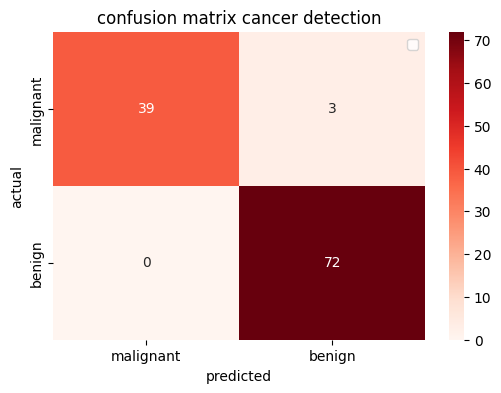

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score,recall_score
best_model=gridsearchcv.best_estimator_
y_pred=best_model.predict(x_test)
print(f"accuracy: {accuracy_score(y_test,y_pred)}")
print(f"recall: {recall_score(y_test,y_pred)}")
print(f"roc_auc: {roc_auc_score(y_test,y_pred)}")
print(classification_report(y_test,y_pred,target_names=['malignant','benign']))
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',xticklabels=['malignant','benign'],yticklabels=['malignant','benign'],cmap='Reds')
plt.title("confusion matrix cancer detection")
plt.xlabel('predicted')
plt.ylabel('actual')
plt.legend()
plt.show()